# 数据预处理

In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [2]:
# 读取每个 Excel 文件
df1 = pd.read_excel('../data/raw_data_2011-2025/RESSET_DRESSTK_2016_2020_1.xlsx')
df2 = pd.read_excel('../data/raw_data_2011-2025/RESSET_DRESSTK_2011_2015_1.xlsx')
df3 = pd.read_excel('../data/raw_data_2011-2025/RESSET_DRESSTK_2021__1.xlsx')

# 合并数据框
combined_df = pd.concat([df1, df2, df3], ignore_index=True)
combined_df.head()

,公司代码_CompanyCode,证券代码_R_SecuCode,上市公司代码_Comcd,股票代码_Stkcd,最新股票名称_Lstknm,交易时股票代码_Stkcdotrd,上市状态_Listedstate,证监会行业门类代码_Csrciccd1,证监会行业大类代码_Csrciccd2,日期_Date,...,截止日期_Enddt,报表类型_Reporttype,每股收益(摊薄)(元/股)_EPS,净资产收益率(摊薄)(%)_ROE,每股公积金(元/股)_AccumFundPS,每股营业利润(元/股)_OpPrfPS,每股净资产(元/股)_NAPS,调整后每股净资产(元/股)_NAPSadj,每股营业收入(元/股)_IncomePS,每股经营活动现金流量净额(元/股)_NCFfropePS
0,3.0,90_000001,C000001,1,平安银行,1.0,Norm,J,J66,2016-01-04,...,2015-09-30,Q3,1.24,11.2896,4.59,1.63,10.98,3.25,4.97,6.43
1,3.0,90_000001,C000001,1,平安银行,1.0,Norm,J,J66,2016-01-05,...,2015-09-30,Q3,1.24,11.2896,4.59,1.63,10.98,3.25,4.97,6.43
2,3.0,90_000001,C000001,1,平安银行,1.0,Norm,J,J66,2016-01-06,...,2015-09-30,Q3,1.24,11.2896,4.59,1.63,10.98,3.25,4.97,6.43
3,3.0,90_000001,C000001,1,平安银行,1.0,Norm,J,J66,2016-01-07,...,2015-09-30,Q3,1.24,11.2896,4.59,1.63,10.98,3.25,4.97,6.43
4,3.0,90_000001,C000001,1,平安银行,1.0,Norm,J,J66,2016-01-08,...,2015-09-30,Q3,1.24,11.2896,4.59,1.63,10.98,3.25,4.97,6.43


In [3]:
# 打印 filtered_combined_df 的基本信息
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275124 entries, 0 to 275123
Data columns (total 75 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   公司代码_CompanyCode              273584 non-null  float64
 1   证券代码_R_SecuCode               273584 non-null  object 
 2   上市公司代码_Comcd                  275112 non-null  object 
 3   股票代码_Stkcd                    275124 non-null  int64  
 4   最新股票名称_Lstknm                 273584 non-null  object 
 5   交易时股票代码_Stkcdotrd             273584 non-null  float64
 6   上市状态_Listedstate              273639 non-null  object 
 7   证监会行业门类代码_Csrciccd1           273584 non-null  object 
 8   证监会行业大类代码_Csrciccd2           273584 non-null  object 
 9   日期_Date                       275124 non-null  object 
 10  前收盘价(元)_PrevClPr              265941 non-null  float64
 11  开盘价(元)_Oppr                   265941 non-null  float64
 12  最高价(元)_Hipr                   265941 non-nul

In [4]:
total_rows = len(combined_df)
print(f"Total number of rows: {total_rows}")

Total number of rows: 275124


## 数据清洗

In [5]:
# 删除指定列
columns_to_drop = [
    '股票拆细比例(股)_Stksprate', '缩股比例(股)_Shrcmprsrate', '增发价格(元)_Snipr', 
    '增发新股数(股)_Snivol', '对价派现金额(元)_Pcash', '对价送股比例_Pshrrate', 
    '对价送股比例_公司送股_Pshrrate_C', '对价送股比例_非流通股东送股_Pshrrate_S', 
    '对价转增比例_Pcapissurate','除权除息日_Exdt','股数变动日_Capchgdt','现金红利(元)_Dividend',
    '送股比例(股)_Stkdrate','转增比例(股)_Capissurate','配股比例(股)_Rigoffrate','配股价格(元)_Rigoffpr',
    '实际配股数(股)_Arigoffshr'
]

# 删除列并更新数据框
combined_df = combined_df.drop(columns=columns_to_drop)

# 显示删除后的数据框信息
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275124 entries, 0 to 275123
Data columns (total 58 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   公司代码_CompanyCode              273584 non-null  float64
 1   证券代码_R_SecuCode               273584 non-null  object 
 2   上市公司代码_Comcd                  275112 non-null  object 
 3   股票代码_Stkcd                    275124 non-null  int64  
 4   最新股票名称_Lstknm                 273584 non-null  object 
 5   交易时股票代码_Stkcdotrd             273584 non-null  float64
 6   上市状态_Listedstate              273639 non-null  object 
 7   证监会行业门类代码_Csrciccd1           273584 non-null  object 
 8   证监会行业大类代码_Csrciccd2           273584 non-null  object 
 9   日期_Date                       275124 non-null  object 
 10  前收盘价(元)_PrevClPr              265941 non-null  float64
 11  开盘价(元)_Oppr                   265941 non-null  float64
 12  最高价(元)_Hipr                   265941 non-nul

In [6]:
# 查看每个字段的缺失情况
missing_data = combined_df.isnull().sum()
missing_percentage = (missing_data / len(combined_df)) * 100
print(pd.DataFrame({'Missing Values': missing_data, 'Missing Percentage': missing_percentage}))

                              Missing Values  Missing Percentage
公司代码_CompanyCode                        1540            0.559748
证券代码_R_SecuCode                         1540            0.559748
上市公司代码_Comcd                              12            0.004362
股票代码_Stkcd                                 0            0.000000
最新股票名称_Lstknm                           1540            0.559748
交易时股票代码_Stkcdotrd                       1540            0.559748
上市状态_Listedstate                        1485            0.539757
证监会行业门类代码_Csrciccd1                     1540            0.559748
证监会行业大类代码_Csrciccd2                     1540            0.559748
日期_Date                                    0            0.000000
前收盘价(元)_PrevClPr                        9183            3.337768
开盘价(元)_Oppr                             9183            3.337768
最高价(元)_Hipr                             9183            3.337768
最低价(元)_Lopr                             9183            3.337768
收盘价(元)_Clpr              

## 处理缺失值

In [7]:
combined_df = combined_df.drop(columns=['调整后每股净资产(元/股)_NAPSadj'])

In [8]:
combined_df = combined_df.dropna(subset=['公司代码_CompanyCode', '证券代码_R_SecuCode'])

In [9]:
# 删除包含缺失的行
combined_df = combined_df.dropna(subset=[
    '每股收益(摊薄)(元/股)_EPS', 
    '净资产收益率(摊薄)(%)_ROE',
    '每股公积金(元/股)_AccumFundPS', 
    '每股营业利润(元/股)_OpPrfPS',
    '每股净资产(元/股)_NAPS', 
    '每股营业收入(元/股)_IncomePS', 
    '每股经营活动现金流量净额(元/股)_NCFfropePS'
])


In [10]:
num_cols = [
    '总股数(股)_Fullshr', 
    '流通股(股)_Trdshr', 
    '已上市流通股(股)_Lsttrdshr', 
    '市盈率_PE', 
    '市现率_PCF', 
    '市销率_PS', 
    '市净率_PB'
]

# 使用均值填充
imputer_mean = SimpleImputer(strategy='mean')
combined_df[num_cols] = imputer_mean.fit_transform(combined_df[num_cols])


In [11]:
# 对具有缺失的数值型字段使用KNN填充
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5)

# 选择数值型列
num_cols_to_impute = ['市盈率_PE', '市净率_PB', '每股公积金(元/股)_AccumFundPS']
combined_df[num_cols_to_impute] = knn_imputer.fit_transform(combined_df[num_cols_to_impute])

In [12]:
# 对于价格相关字段：使用相邻日期的值填充（如前一天的收盘价）或使用插值方法
combined_df['前收盘价(元)_PrevClPr'] = combined_df['前收盘价(元)_PrevClPr'].fillna(method='ffill')
combined_df['开盘价(元)_Oppr'] = combined_df['开盘价(元)_Oppr'].fillna(method='ffill')
combined_df['最高价(元)_Hipr'] = combined_df['最高价(元)_Hipr'].fillna(method='ffill')
combined_df['最低价(元)_Lopr'] = combined_df['最低价(元)_Lopr'].fillna(method='ffill')
combined_df['收盘价(元)_Clpr'] = combined_df['收盘价(元)_Clpr'].fillna(method='ffill')
combined_df['复权价1(元)_AdjClpr1'] = combined_df['复权价1(元)_AdjClpr1'].fillna(method='ffill')
combined_df['复权价2(元)_AdjClpr2'] = combined_df['复权价2(元)_AdjClpr2'].fillna(method='ffill')

In [13]:
df = combined_df.dropna(subset=['公司代码_CompanyCode', '证券代码_R_SecuCode', '最新股票名称_Lstknm', '交易时股票代码_Stkcdotrd'])

In [14]:
# 对于没有成交量或成交金额的记录，填充为0表示当天没有交易
combined_df['成交量(股)_Trdvol'] = combined_df['成交量(股)_Trdvol'].fillna(0)
combined_df['成交金额(元)_Trdsum'] = combined_df['成交金额(元)_Trdsum'].fillna(0)

In [15]:
# 日振幅、流通股日换手率和总股数日换手率使用等使用前向或后向填充，保持换手率的时间连续性
combined_df['日振幅()_Dampltd'] = combined_df['日振幅()_Dampltd'].fillna(method='ffill')
combined_df['总股数日换手率()_DFulTurnR'] = combined_df['总股数日换手率()_DFulTurnR'].fillna(method='ffill')
combined_df['流通股日换手率()_DTrdTurnR'] = combined_df['流通股日换手率()_DTrdTurnR'].fillna(method='ffill')

In [16]:
# 公司国有股和法人股数据缺失用0填充
combined_df['公司国有股(股)_Comstateshr'].fillna(0, inplace=True)
combined_df['公司法人股(股)_Comlpshr'].fillna(0, inplace=True)

In [17]:
# 考虑收益率和资本收益率、累积股价调整乘子等的数据点在时间序列中有一定的趋势，使用插值法来填充缺失值
combined_df['累积股价调整乘子_Mcfacpr'] = combined_df['累积股价调整乘子_Mcfacpr'].interpolate(method='linear')
combined_df['日收益率_Dret'] = combined_df['日收益率_Dret'].interpolate(method='linear')
combined_df['日资本收益率_Daret'] = combined_df['日资本收益率_Daret'].interpolate(method='linear')
combined_df['等权平均市场日收益率_Dreteq'] = combined_df['等权平均市场日收益率_Dreteq'].interpolate(method='linear')
columns_to_interpolate = [
    '流通市值加权平均市场日收益率_Drettmv',
    '总市值加权平均市场日收益率_Dretmc',
    '等权平均市场日资本收益率_Dareteq',
    '流通市值加权平均市场日资本收益_Darettmv',
    '总市值加权平均日资本收益_Daretmc',
    '日无风险收益率_DRfRet'
]

for col in columns_to_interpolate:
    combined_df[col] = combined_df[col].interpolate(method='linear')

In [18]:
# 汇率在短时间内的波动通常较小，使用前向或后向填充方法，保持数据的连续性
combined_df['汇率_Ex'] = combined_df['汇率_Ex'].fillna(method='ffill').fillna(method='bfill')

In [19]:
# 由于佣金和印花税通常稳定，使用均值填充来处理。
mean_coma = combined_df['A股佣金(元)_Coma'].mean()
combined_df['A股佣金(元)_Coma'] = combined_df['A股佣金(元)_Coma'].fillna(mean_coma)
combined_df['市盈率_PE'] = combined_df.groupby('证监会行业大类代码_Csrciccd2')['市盈率_PE'].transform(lambda x: x.fillna(x.mean()))
combined_df['市净率_PB'] = combined_df['市净率_PB'].fillna(combined_df['市净率_PB'].mean())
columns_to_fill_mean = [
    'B股佣金(元)_Comb',
    'A股印花税_Stamptaxa',
    'B股印花税_Stamptaxb',
    '市现率_PCF',
    '市销率_PS'
]
for col in columns_to_fill_mean:
    combined_df[col] = combined_df.groupby('证监会行业大类代码_Csrciccd2')[col].transform(lambda x: x.fillna(x.mean()))

In [20]:
# 类别型字段
cat_cols = [
    '上市状态_Listedstate', 
    '证监会行业门类代码_Csrciccd1', 
    '证监会行业大类代码_Csrciccd2', 
    '报价货币_Qttncurrency', 
    'B股佣金(元)_Comb', 
    'A股印花税_Stamptaxa', 
    'B股印花税_Stamptaxb'
]

# 使用众数填充类别型字段
imputer_mode = SimpleImputer(strategy='most_frequent')
combined_df[cat_cols] = imputer_mode.fit_transform(combined_df[cat_cols])

In [21]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 273584 entries, 0 to 275123
Data columns (total 57 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   公司代码_CompanyCode              273584 non-null  float64
 1   证券代码_R_SecuCode               273584 non-null  object 
 2   上市公司代码_Comcd                  273584 non-null  object 
 3   股票代码_Stkcd                    273584 non-null  int64  
 4   最新股票名称_Lstknm                 273584 non-null  object 
 5   交易时股票代码_Stkcdotrd             273584 non-null  float64
 6   上市状态_Listedstate              273584 non-null  object 
 7   证监会行业门类代码_Csrciccd1           273584 non-null  object 
 8   证监会行业大类代码_Csrciccd2           273584 non-null  object 
 9   日期_Date                       273584 non-null  object 
 10  前收盘价(元)_PrevClPr              273584 non-null  float64
 11  开盘价(元)_Oppr                   273584 non-null  float64
 12  最高价(元)_Hipr                   273584 non-null  fl

In [22]:
combined_df.to_csv('../data/combined_data.csv', index=False, encoding='utf-8')

## 去除重复值

In [54]:
combined_df = pd.read_csv('../data/combined_data.csv')
combined_df.drop_duplicates(inplace=True)

## 数据类型转换

In [69]:
# 确保日期列是datetime类型
combined_df['日期_Date'] = pd.to_datetime(combined_df['日期_Date'])
# 将分类变量转换为category类型
combined_df['上市状态_Listedstate'] = combined_df['上市状态_Listedstate'].astype('category')

## 确定研究对象（2011-2025年内均在市金融机构）

In [70]:
total_companies = combined_df['公司代码_CompanyCode'].nunique()
print(f"金融机构数量：{total_companies}家")

combined_df['年份'] = combined_df['日期_Date'].dt.year

# 计算每年都有记录的公司
companies_per_year = combined_df.groupby('公司代码_CompanyCode')['年份'].nunique()

# 筛选出15年数据全都有的公司（即每家公司都有2011-2025年的记录）
companies_full_data = companies_per_year[companies_per_year == 15]

# 计算15年数据全都有的公司数量
companies_with_full_data = companies_full_data.count()
print(f"15年数据全都有的金融机构数量：{companies_with_full_data}家")

金融机构数量：110家
15年数据全都有的金融机构数量：45家


In [57]:
companies_full_data_list = combined_df[combined_df['公司代码_CompanyCode'].isin(companies_full_data.index)]['最新股票名称_Lstknm'].unique()
print(f"15年数据全都有的金融机构：{companies_full_data_list}")

filtered_combined_df = combined_df[combined_df['公司代码_CompanyCode'].isin(companies_full_data.index)]
filtered_combined_df.shape[0]

15年数据全都有的金融机构：['平安银行' '华金资本' '陕国投A' '海德股份' '中油资本' '东北证券' '锦龙股份' '国元证券' '国海证券' '广发证券'
 '长江证券' '电投产融' '越秀资本' '宁波银行' '中粮资本' '山西证券' '东方财富' '新国都' '浦发银行' '华夏银行'
 '民生银行' '中信证券' '招商银行' '九鼎投资' '国投资本' '湘财股份' '国金证券' '浙江东方' '华创云信' '新力金融'
 '西南证券' '五矿资本' '华鑫股份' '爱建集团' '建元信托' '香溢融通' '亚泰集团' '招商证券' '南京银行' '太平洋'
 '兴业银行' '北京银行' '农业银行' '中国平安' '交通银行']


162871

In [58]:
filtered_combined_df.head()

,公司代码_CompanyCode,证券代码_R_SecuCode,上市公司代码_Comcd,股票代码_Stkcd,最新股票名称_Lstknm,交易时股票代码_Stkcdotrd,上市状态_Listedstate,证监会行业门类代码_Csrciccd1,证监会行业大类代码_Csrciccd2,日期_Date,...,截止日期_Enddt,报表类型_Reporttype,每股收益(摊薄)(元/股)_EPS,净资产收益率(摊薄)(%)_ROE,每股公积金(元/股)_AccumFundPS,每股营业利润(元/股)_OpPrfPS,每股净资产(元/股)_NAPS,每股营业收入(元/股)_IncomePS,每股经营活动现金流量净额(元/股)_NCFfropePS,年份
0,3.0,90_000001,C000001,1,平安银行,1.0,Norm,J,J66,2016-01-04,...,2015-09-30,Q3,1.24,11.2896,4.59,1.63,10.98,4.97,6.43,2016
1,3.0,90_000001,C000001,1,平安银行,1.0,Norm,J,J66,2016-01-05,...,2015-09-30,Q3,1.24,11.2896,4.59,1.63,10.98,4.97,6.43,2016
2,3.0,90_000001,C000001,1,平安银行,1.0,Norm,J,J66,2016-01-06,...,2015-09-30,Q3,1.24,11.2896,4.59,1.63,10.98,4.97,6.43,2016
3,3.0,90_000001,C000001,1,平安银行,1.0,Norm,J,J66,2016-01-07,...,2015-09-30,Q3,1.24,11.2896,4.59,1.63,10.98,4.97,6.43,2016
4,3.0,90_000001,C000001,1,平安银行,1.0,Norm,J,J66,2016-01-08,...,2015-09-30,Q3,1.24,11.2896,4.59,1.63,10.98,4.97,6.43,2016


In [59]:
# 指定需要对数转换的收益率字段
return_columns = ['日收益率_Dret', '日资本收益率_Daret', 
                  '等权平均市场日收益率_Dreteq', '流通市值加权平均市场日收益率_Drettmv',
                  '总市值加权平均市场日收益率_Dretmc', '等权平均市场日资本收益率_Dareteq', '日无风险收益率_DRfRet']

# 对收益率字段进行对数转换（加1以避免负值问题）
for col in return_columns:
    filtered_combined_df[col] = np.log1p(filtered_combined_df[col])

# 检查转换结果
filtered_combined_df[return_columns].head()

,日收益率_Dret,日资本收益率_Daret,等权平均市场日收益率_Dreteq,流通市值加权平均市场日收益率_Drettmv,总市值加权平均市场日收益率_Dretmc,等权平均市场日资本收益率_Dareteq,日无风险收益率_DRfRet
0,-0.056570,-0.056570,-0.095520,-0.095300,-0.094860,-0.095520,0.000085
1,0.006181,0.006181,-0.025933,-0.020815,-0.020815,-0.025933,0.000085
2,0.011336,0.011336,0.031886,0.027518,0.028782,0.031886,0.000084
3,-0.052557,-0.052557,-0.097613,-0.096621,-0.096291,-0.097613,0.000084
4,0.016365,0.016365,0.007571,0.010445,0.011830,0.007571,0.000084


## 异常值处理

In [60]:
# 根据IQR过滤掉异常值
Q1 = filtered_combined_df['收盘价(元)_Clpr'].quantile(0.25)
Q3 = filtered_combined_df['收盘价(元)_Clpr'].quantile(0.75)
IQR = Q3 - Q1
filtered_combined_df = filtered_combined_df[(filtered_combined_df['收盘价(元)_Clpr'] >= (Q1 - 1.5 * IQR)) & 
                           (filtered_combined_df['收盘价(元)_Clpr'] <= (Q3 + 1.5 * IQR))]

In [62]:
columns_to_check = [
    '流通市值加权平均市场日收益率_Drettmv',
    '总市值加权平均市场日收益率_Dretmc',
    '等权平均市场日资本收益率_Dareteq',
    '流通市值加权平均市场日资本收益_Darettmv',
    '总市值加权平均日资本收益_Daretmc',
    '日无风险收益率_DRfRet',
    '累积股价调整乘子_Mcfacpr',
    '日资本收益率_Daret',
    '等权平均市场日收益率_Dreteq'
]

# 计算每行中指定字段的非0值个数
non_zero_counts = (filtered_combined_df[columns_to_check] != 0).sum(axis=1)

# 找出非0值小于等于2的行数
count = (non_zero_counts <= 2).sum()

print(f"非0值小于等于2的行数: {count}")

非0值小于等于2的行数: 0


In [63]:
filtered_combined_df.to_csv('../data/combined_data_log.csv', index=False)

In [83]:
len(filtered_combined_df)

152068

## 使用筛选有完整数据的45家金融机构数据计算日收益率

In [93]:
filtered_combined_df = pd.read_csv('../data/combined_data_log.csv')  # 假设原始数据

In [94]:
institutions_df = pd.read_excel('../data/金融机构对照.xlsx', header=0)  # 加载金融机构对照数据
institutions_df.columns = ['中文名称', '英文缩写','分类']


filtered_combined_df.sort_values(by=['证券代码_R_SecuCode', '日期_Date'], inplace=True)
filtered_combined_df = filtered_combined_df.merge(institutions_df, left_on='最新股票名称_Lstknm', right_on='中文名称', how='left')
print("合并后的列名:", filtered_combined_df.columns)

# 计算日收益率
filtered_combined_df['daily_return'] = filtered_combined_df.groupby('证券代码_R_SecuCode')['收盘价(元)_Clpr'].pct_change()
filtered_combined_df.dropna(subset=['daily_return'], inplace=True)
if '英文缩写' not in filtered_combined_df.columns:
    print("列 '英文缩写' 不存在！请检查合并是否成功。")
else:
    workdata_log = filtered_combined_df.pivot_table(index='日期_Date', columns='英文缩写', values='daily_return')

合并后的列名: Index(['公司代码_CompanyCode', '证券代码_R_SecuCode', '上市公司代码_Comcd', '股票代码_Stkcd',
       '最新股票名称_Lstknm', '交易时股票代码_Stkcdotrd', '上市状态_Listedstate',
       '证监会行业门类代码_Csrciccd1', '证监会行业大类代码_Csrciccd2', '日期_Date',
       '前收盘价(元)_PrevClPr', '开盘价(元)_Oppr', '最高价(元)_Hipr', '最低价(元)_Lopr',
       '收盘价(元)_Clpr', '复权价1(元)_AdjClpr1', '复权价2(元)_AdjClpr2', '成交量(股)_Trdvol',
       '成交金额(元)_Trdsum', '日振幅()_Dampltd', '总股数日换手率()_DFulTurnR',
       '流通股日换手率()_DTrdTurnR', '公司国有股(股)_Comstateshr', '公司法人股(股)_Comlpshr',
       '总股数(股)_Fullshr', '流通股(股)_Trdshr', '已上市流通股(股)_Lsttrdshr',
       '累积股价调整乘子_Mcfacpr', '报价货币_Qttncurrency', '汇率_Ex', '日收益率_Dret',
       '日资本收益率_Daret', '等权平均市场日收益率_Dreteq', '流通市值加权平均市场日收益率_Drettmv',
       '总市值加权平均市场日收益率_Dretmc', '等权平均市场日资本收益率_Dareteq',
       '流通市值加权平均市场日资本收益_Darettmv', '总市值加权平均日资本收益_Daretmc', '日无风险收益率_DRfRet',
       'A股佣金(元)_Coma', 'B股佣金(元)_Comb', 'A股印花税_Stamptaxa', 'B股印花税_Stamptaxb',
       '市盈率_PE', '市净率_PB', '市现率_PCF', '市销率_PS', '信息发布日期_Infopubdt',
       '截止日期_E

In [95]:
workdata_log.to_excel('../data/workdata_log.xlsx')
workdata_log.head()

英文缩写,ABC,AJG,BJB,BOCOM,CIB,CITICS,CLC,CMB,CMBC,COC,...,SWZ,SXZ,TPAC,XCF,XGD,XLF,XYR,YTG,YXC,ZDO
日期_Date,,,,,,,,,,,,,,,,,,,,,
2011-01-05,-0.014981,-0.020234,0.000860,0.014440,-0.004050,-0.017761,0.006383,-0.003840,-0.005917,-0.014364,...,-0.014346,-0.018760,-0.004525,0.064840,NaN,0.084906,0.009874,0.010279,0.005212,0.010309
2011-01-06,-0.007605,-0.019565,0.000000,-0.005338,0.007320,-0.005503,0.000000,-0.005397,-0.001984,0.027638,...,0.001712,-0.008313,0.034545,-0.017153,NaN,-0.015942,-0.014222,-0.023256,0.001111,0.004535
2011-01-07,0.015326,0.004435,0.035223,0.019678,0.070650,0.009486,-0.006342,0.027132,0.000000,-0.031785,...,0.012821,0.016764,0.013181,0.005236,NaN,0.023564,-0.011722,0.000000,-0.006289,-0.006772
2011-01-10,-0.007547,-0.030905,-0.026556,-0.019298,-0.034314,-0.026625,-0.038298,-0.017358,0.009940,-0.030303,...,-0.033755,-0.027205,-0.012142,-0.014757,NaN,-0.017266,-0.031934,-0.019345,-0.032018,-0.030682
2011-01-11,0.000000,0.015945,0.019608,0.014311,0.023819,0.008850,-0.006637,0.013057,0.007874,-0.023438,...,0.007860,0.005085,0.011414,-0.036123,NaN,-0.029283,0.005655,0.006070,0.011538,-0.010551


In [112]:
zero_counts = (workdata_log == 0).sum(axis=1)

filtered_data = workdata_log[zero_counts <9 ]
filtered_data.reset_index(inplace=True)
# 输出过滤后的数据行数
print(f"过滤后剩余的数据行数: {len(filtered_data)}")

过滤后剩余的数据行数: 3691


In [113]:
filtered_data.head()

英文缩写,日期_Date,ABC,AJG,BJB,BOCOM,CIB,CITICS,CLC,CMB,CMBC,...,SWZ,SXZ,TPAC,XCF,XGD,XLF,XYR,YTG,YXC,ZDO
0,2011-01-05,-0.014981,-0.020234,0.000860,0.014440,-0.004050,-0.017761,0.006383,-0.003840,-0.005917,...,-0.014346,-0.018760,-0.004525,0.064840,NaN,0.084906,0.009874,0.010279,0.005212,0.010309
1,2011-01-06,-0.007605,-0.019565,0.000000,-0.005338,0.007320,-0.005503,0.000000,-0.005397,-0.001984,...,0.001712,-0.008313,0.034545,-0.017153,NaN,-0.015942,-0.014222,-0.023256,0.001111,0.004535
2,2011-01-07,0.015326,0.004435,0.035223,0.019678,0.070650,0.009486,-0.006342,0.027132,0.000000,...,0.012821,0.016764,0.013181,0.005236,NaN,0.023564,-0.011722,0.000000,-0.006289,-0.006772
3,2011-01-10,-0.007547,-0.030905,-0.026556,-0.019298,-0.034314,-0.026625,-0.038298,-0.017358,0.009940,...,-0.033755,-0.027205,-0.012142,-0.014757,NaN,-0.017266,-0.031934,-0.019345,-0.032018,-0.030682
4,2011-01-11,0.000000,0.015945,0.019608,0.014311,0.023819,0.008850,-0.006637,0.013057,0.007874,...,0.007860,0.005085,0.011414,-0.036123,NaN,-0.029283,0.005655,0.006070,0.011538,-0.010551


In [114]:
# 前向填充和向后填充
filtered_data = filtered_data.fillna(method='ffill')
filtered_data = filtered_data.fillna(method='bfill')

In [115]:
output_file_path = '../data/filtered_workdata_log.xlsx'
filtered_data.to_excel(output_file_path, index=False)
print(f"过滤后的数据已保存为: {output_file_path}")

过滤后的数据已保存为: ../data/filtered_workdata_log.xlsx


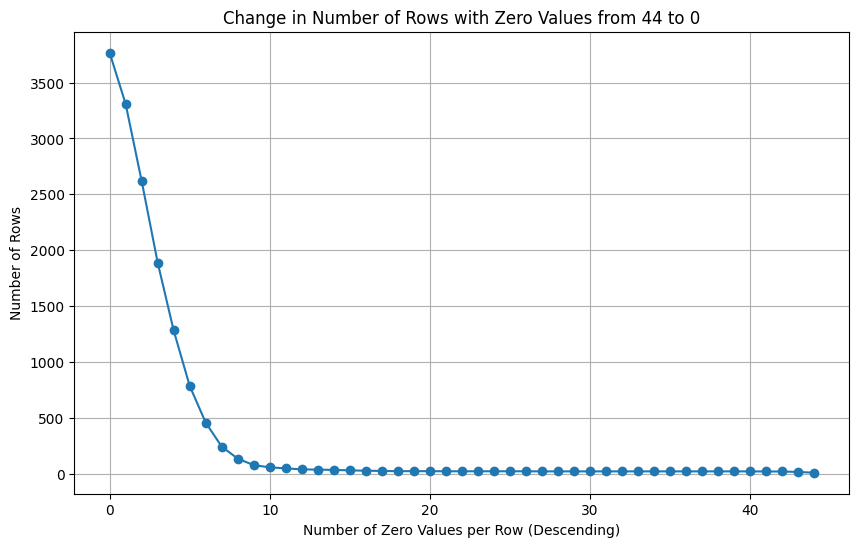

In [116]:
zero_counts = (workdata_log == 0).sum(axis=1)

# 可视化 0 值数量从 44 到 0 的行数变化折线图
zero_counts_distribution = [(zero_counts >= i).sum() for i in range(44, -1, -1)]
plt.figure(figsize=(10, 6))
plt.plot(range(44, -1, -1), zero_counts_distribution, marker='o')
plt.xlabel('Number of Zero Values per Row (Descending)')
plt.ylabel('Number of Rows')
plt.title('Change in Number of Rows with Zero Values from 44 to 0')
plt.grid(True)
plt.show()

In [5]:
import pandas as pd
import os

# 1. 设置路径
garch_folder = "../differenced_data/GARCH_result/"
output_file = "../tvpdata_log.xlsx"

# 2. 读取日期列
filtered_data = pd.read_excel("../data/filtered_workdata_log.xlsx")
dates = filtered_data['日期_Date']

# 3. 创建空的 DataFrame，先放日期
tvp_df = pd.DataFrame({'Date': dates})

# 4. 遍历 GARCH_result 文件夹，读取每个金融机构的波动率
for filename in os.listdir(garch_folder):
    if filename.endswith(".xlsx") and not filename.startswith("~$"):
        file_path = os.path.join(garch_folder, filename)
        df = pd.read_excel(file_path)
        tvp_df[filename.replace(".xlsx","")] = df.iloc[:,0]

# 5. 保存合并后的 tvpdata_log.xlsx
tvp_df.dropna(how='all', inplace=True)
tvp_df.fillna(method='ffill', inplace=True)  # 前向填充
tvp_df.to_excel(output_file, index=False)
print(f"tvpdata_log.xlsx 已生成，路径：{output_file}")


/var/folders/rd/6xysg4fx11d5lkjc101qjx6w0000gn/T/ipykernel_50886/1008418181.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  tvp_df.fillna(method='ffill', inplace=True)  # 前向填充


tvpdata_log.xlsx 已生成，路径：../tvpdata_log.xlsx
